# Text Mining Project — Data Exploration
**Spring Semester 2025/2026**

Group 11:
- Ana Macedo
- Carlota Pires
- Francisca Calçoa
- Francisca Martins

This notebook covers **Section 1 – Data Exploration** of the project requirements.


## 1. Imports and Setup

In [1]:
!pip install wordcloud
!pip install emoji
!pip install fasttext-wheel


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
import gensim
import gensim.downloader

from wordcloud import WordCloud
from tqdm import tqdm

#for splitting data
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import nltk
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from gensim.models import Word2Vec

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



# Additional libraries for advanced modeling and preprocessing

import fasttext

## 2. Load the Data

In [3]:
train = pd.read_csv('../Datasets/train.csv')
test  = pd.read_csv('../Datasets/test.csv')

In [4]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Label mapping for readability
label_map  = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
label_colors = {'Bearish': '#e58181', 'Bullish': '#c4ebc4', 'Neutral': '#fff3b1'}

# Add readable label column
train['sentiment'] = train['label'].map(label_map)

## 3. Basic Dataset Overview

In [5]:
#Verification of the loaded data
print(f'Train set : {train.shape[0]:,} tweets, {train.shape[1]} columns')
print(f'Test set  : {test.shape[0]:,} tweets, {test.shape[1]} columns')
train.head(10)

Train set : 9,543 tweets, 3 columns
Test set  : 2,388 tweets, 2 columns


,text,label,sentiment
0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,Bearish
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0,Bearish
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0,Bearish
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0,Bearish
8,$GTT: Cowen cuts to Market Perform,0,Bearish
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0,Bearish


In [6]:
train.tail(10)

,text,label,sentiment
9533,"Stocks making the biggest moves midday: Tesla,...",2,Neutral
9534,"Stocks making the biggest moves midday: Tesla,...",2,Neutral
9535,"Stocks making the biggest moves midday: Uber, ...",2,Neutral
9536,Stocks making the biggest moves premarket: Tar...,2,Neutral
9537,Stocks making the biggest moves premarket: TD ...,2,Neutral
9538,The Week's Gainers and Losers on the Stoxx Eur...,2,Neutral
9539,Tupperware Brands among consumer gainers; Unil...,2,Neutral
9540,vTv Therapeutics leads healthcare gainers; Myo...,2,Neutral
9541,"WORK, XPO, PYX and AMKR among after hour movers",2,Neutral
9542,"YNDX, I, QD and OESX among tech movers",2,Neutral


In [7]:
print(f'Training set Duplicates: {train.duplicated(subset="text").sum()}')

Training set Duplicates: 0


In [8]:
print('Data Types:')
print(train.dtypes)
print()
print('Missing Values:')
print(train.isnull().sum())
print()
print('Test Set Columns:')
print(test.columns.tolist())
print(test.head(3))

Data Types:
text         object
label         int64
sentiment    object
dtype: object

Missing Values:
text         0
label        0
sentiment    0
dtype: int64

Test Set Columns:
['id', 'text']
   id                                               text
0   0  ETF assets to surge tenfold in 10 years to $50...
1   1  Here’s What Hedge Funds Think Evolution Petrol...
2   2  $PVH - Phillips-Van Heusen Q3 2020 Earnings Pr...


In [9]:
print(train['label'].describe())
print(f"\nUnique values: {sorted(train['label'].unique())}")

count    9543.000000
mean        1.496280
std         0.743139
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         2.000000
Name: label, dtype: float64

Unique values: [0, 1, 2]


## 4. Class Distribution

Understanding class balance is critical: if one class dominates, a naive classifier that always predicts that class will have artificially high accuracy.

In [10]:
counts = train['label'].value_counts().sort_index()
total  = len(train)

print('Class distribution (training set):')
for label, count in counts.items():
    name = label_map[label]
    print(f'  {name:8s} ({label}): {count:,}  ({count / total * 100:.1f}%)')

majority_acc = counts.max() / total * 100
print(f'\nMajority-class baseline accuracy: {majority_acc:.1f}%')
print('-> A model must beat this to be useful.')

Class distribution (training set):
  Bearish  (0): 1,442  (15.1%)
  Bullish  (1): 1,923  (20.2%)
  Neutral  (2): 6,178  (64.7%)

Majority-class baseline accuracy: 64.7%
-> A model must beat this to be useful.


**Conclusions:**
- The dataset is imbalanced: ~64.7% of tweets are Neutral, while Bearish (15.1%) and Bullish (20.2%) are underrepresented.
- The majority-class baseline achieves ~64.7% accuracy.
- Class imbalance must be addressed during preprocessing and modelling through for example class weights or oversampling.

Through the class imbalanced, we will choose the F1-score as our evaluation metric. Accuracy can be misleading in imbalanced datasets, as a model could achieve high accuracy by simply predicting the majority class. The F1-score, on the other hand, considers both precision and recall, providing a more balanced evaluation of model performance.

In [11]:
train['word_count'] = train['text'].apply(lambda x: len(str(x).split()))
train['char_count'] = train['text'].apply(lambda x: len(str(x)))

print('Word count statistics by class:')
print(train.groupby('sentiment')['word_count'].describe().round(2))

Word count statistics by class:
            count   mean   std  min  25%   50%   75%   max
sentiment                                                 
Bearish    1442.0  12.00  4.31  3.0  9.0  11.0  15.0  32.0
Bullish    1923.0  11.93  4.32  2.0  9.0  11.0  14.0  29.0
Neutral    6178.0  12.30  4.84  1.0  9.0  12.0  16.0  29.0


**Conclusion:** Tweets are generally short (~12 words on average), consistent across all three classes.


C:\Users\calco\AppData\Local\Temp\ipykernel_18356\3385815743.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


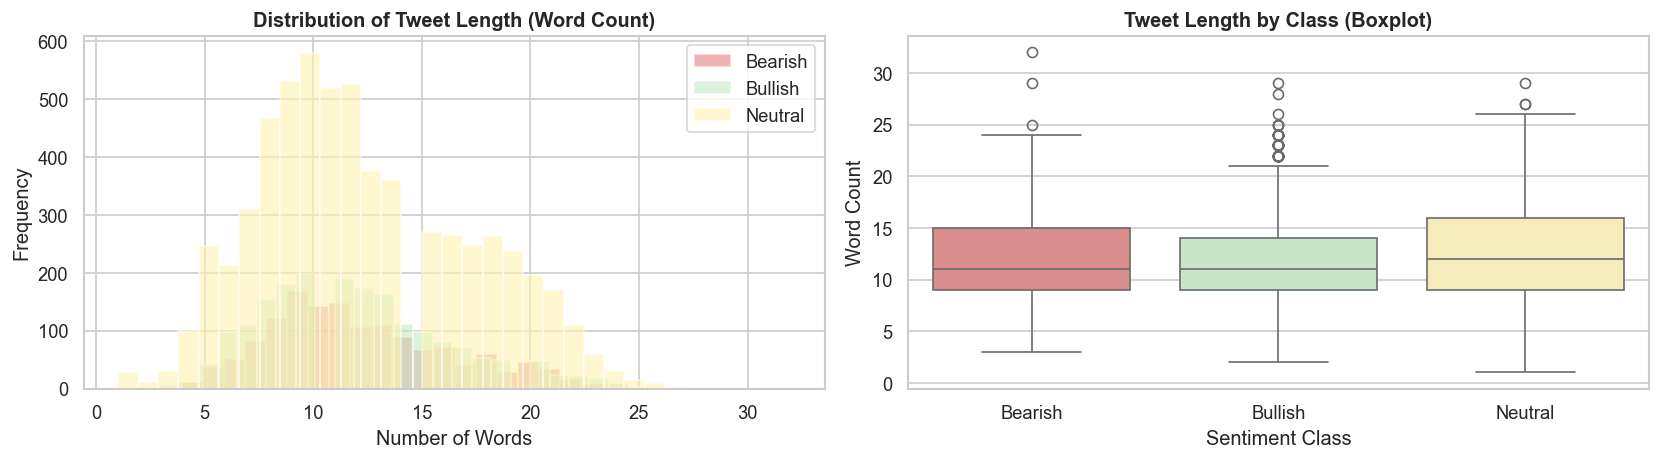

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label_id, label_name in label_map.items():
    subset = train[train['label'] == label_id]['word_count']
    axes[0].hist(subset, bins=30, alpha=0.6, label=label_name,
                 color=label_colors[label_name],
                 edgecolor='white')

axes[0].set_title('Distribution of Tweet Length (Word Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(
    data=train, x='sentiment', y='word_count',
    palette=label_colors,
    order=['Bearish', 'Bullish', 'Neutral'],
    ax=axes[1]
)

axes[1].set_title('Tweet Length by Class (Boxplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('tweet_length.png', bbox_inches='tight')
plt.show()

In [13]:
train['has_ticker']  = train['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', x)))
train['has_hashtag'] = train['text'].apply(lambda x: bool(re.search(r'#\w+', x)))
train['has_url']     = train['text'].apply(lambda x: bool(re.search(r'http', x)))

feature_cols = ['has_ticker', 'has_hashtag', 'has_url']
feature_labels = ['Stock Ticker ($)', 'Hashtag (#)', 'URL (http)']

print('Presence of Twitter-specific features (% of tweets):')
for col, lbl in zip(feature_cols, feature_labels):
    print(f'  {lbl:20s}: {train[col].mean()*100:.1f}%')

Presence of Twitter-specific features (% of tweets):
  Stock Ticker ($)    : 15.0%
  Hashtag (#)         : 9.4%
  URL (http)          : 46.8%


**Conclusions:**
- Stock tickers like `$AAPL` and `$TSLA` appear in ~15% of tweets and are specific to financial sentiment
- Hashtags appear in ~9% of tweets, so their contribution to sentiment may vary.
- URLs are present in ~47% of tweets. They carry no semantic value and should be removed during preprocessing.

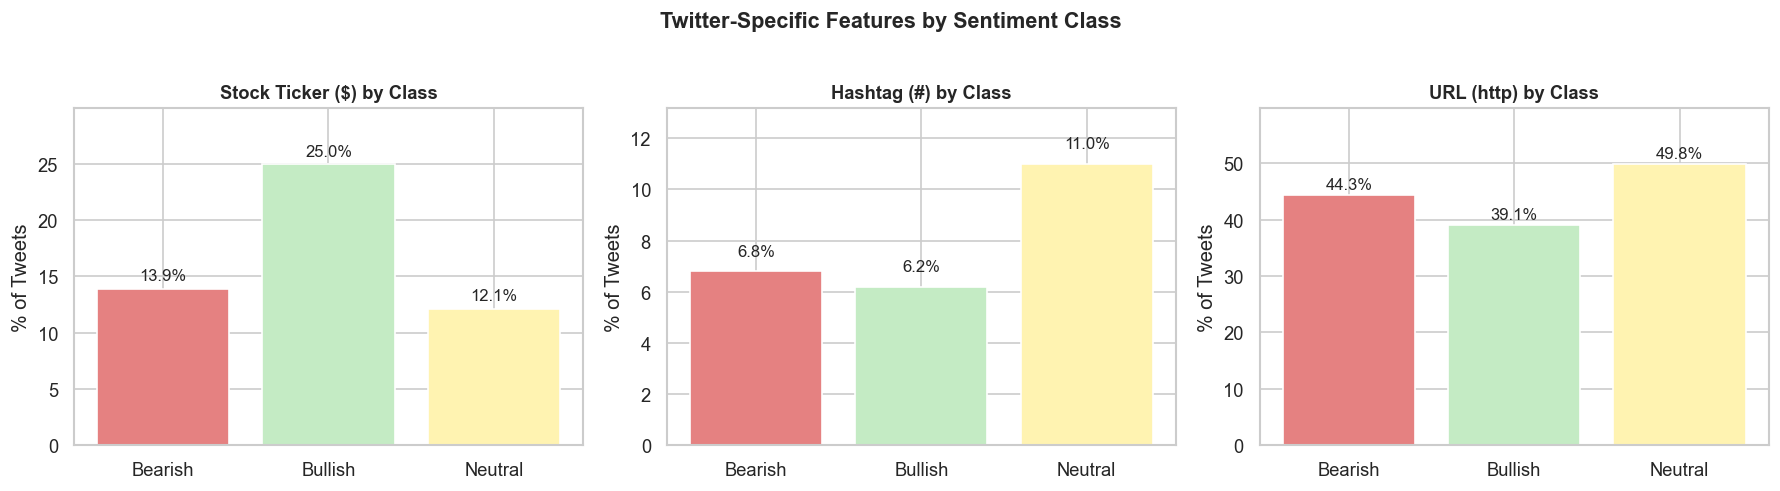

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, lbl in zip(axes, feature_cols, feature_labels):
    data = train.groupby('sentiment')[col].mean() * 100
    data = data.reindex(['Bearish', 'Bullish', 'Neutral'])
    colors = [label_colors[k] for k in ['Bearish', 'Bullish', 'Neutral']]
    bars = ax.bar(data.index, data.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{lbl} by Class', fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Tweets')
    ax.set_ylim(0, data.max() * 1.2)

plt.suptitle('Twitter-Specific Features by Sentiment Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('twitter_features.png', bbox_inches='tight')
plt.show()

**Conclusions:**
- Stock Tickers ($): Bullish has 25% vs Bearish 13.9%. This means that tweets with tickers are more associated with positive sentiment.
- Hashtags (#): Little difference between classes (6-11%), so they have low discriminative power.
- URLs (http): Appear a lot across all classes relatively uniformly, so they do not distinguish sentiment and should be removed in preprocessing. 

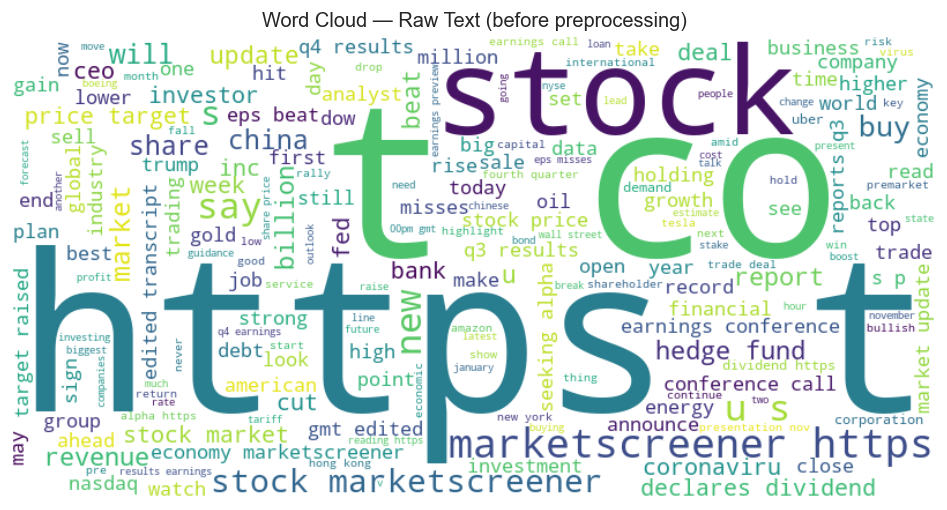

In [15]:
# Word Cloud — Raw Text
raw_text = ' '.join(train['text'].fillna('')).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text (before preprocessing)')
plt.show()

On word clouds (raw text) it's possible to see the most common words in the dataset, but they are not very informative due to the presence of stopwords, punctuation, and other noise. After preprocessing, we will be able to see more meaningful words that are relevant to the sentiment analysis task. Otherwise, "https", "stock" and "marketscreener" are examples of common words that appear in the raw word cloud.

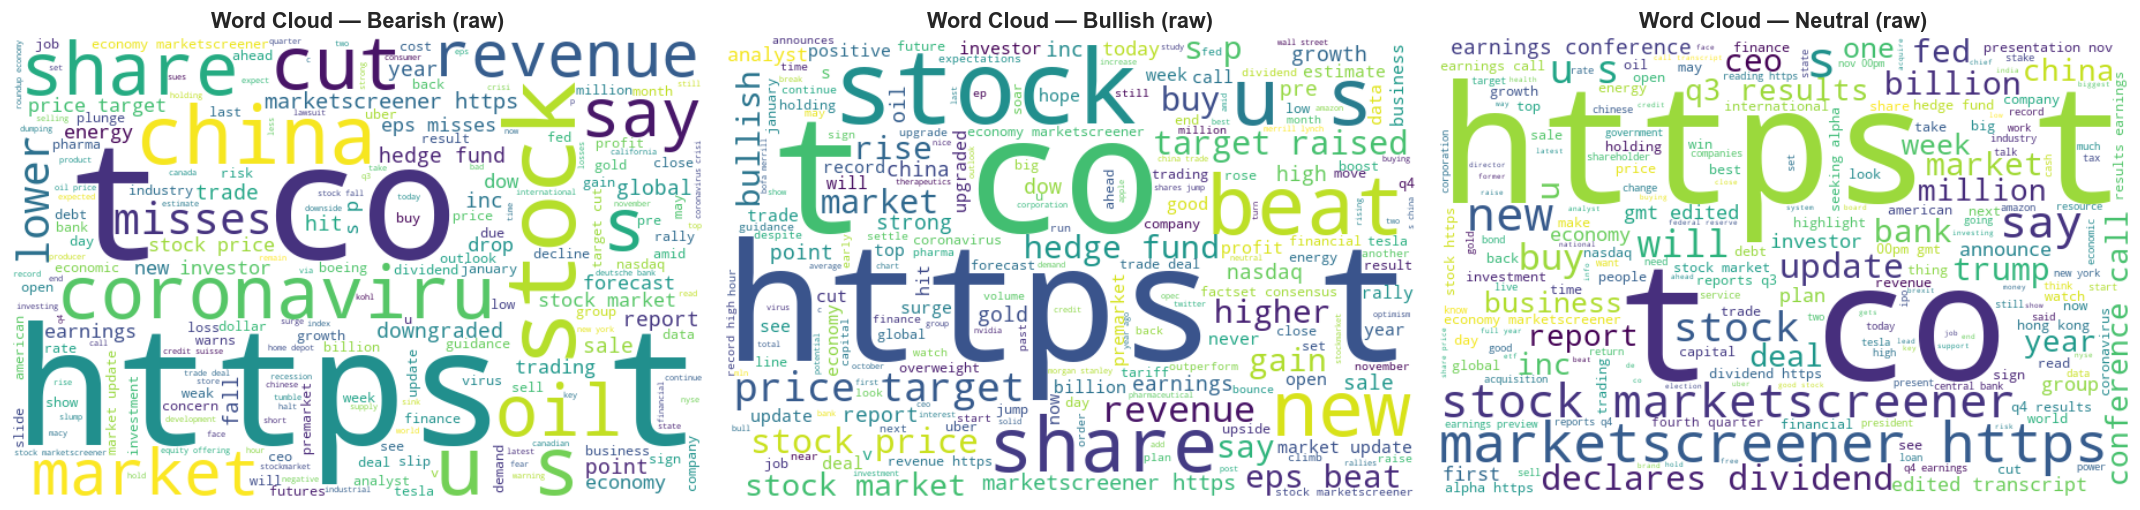

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label_id, label_name) in zip(axes, [(0,'Bearish'), (1,'Bullish'), (2,'Neutral')]):
    text = ' '.join(train[train['label'] == label_id]['text'].fillna('')).lower()
    wc = WordCloud(width=600, height=400, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {label_name} (raw)', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

Through the word clouds for each sentiment class, we can see that:
- Bearish Tweets often contain words like "drop", "fall"
- Bullish Tweets frequently include words such as "buy", "revenue"
- Neutral Tweets have more generic words like "stock", "market"

## 5. Preprocessing

### 5.1 Language of the tweets

In [17]:
# !curl -O https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin
# !pip install numpy==1.26.4

In [18]:
model = fasttext.load_model("lid.176.bin")

def detect_language_fasttext(text):
    try:
        text_cleaned = text.replace('\n', ' ').strip()
        prediction = model.predict(text_cleaned)[0][0]
        return prediction.replace("__label__", "")
    except:
        return "unknown"

train['language'] = train['text'].apply(detect_language_fasttext)
print(train['language'].value_counts())

language
en    9450
de      25
es      16
fr      11
it      10
ja       7
nl       6
pt       5
fi       2
zh       2
sv       2
hr       1
da       1
uz       1
cs       1
vi       1
hu       1
is       1
Name: count, dtype: int64


In [19]:
# See texts that are not english
non_english = train[train['language'] != 'en']
print(f'Non-english tweets in train dataset: {len(non_english)}')
print()
non_english[['text', 'language']].head(10)


Non-english tweets in train dataset: 93



,text,language
1414,DOMTAR CORPORATION COMMUNIQUE LES RÉSULTATS PR...,es
1439,E-Porsche auf Eispiste: Das Rennsport-Comeback...,de
1449,Eudonet annonce un chiffre d’affaires récurren...,fr
1578,Ilkka-Yhtymä Oyj: Johdon liiketoimet #Stock #M...,fi
1831,Resumen: SFL publica los resultados de 2019,es
1837,Rio Tinto’s Giant Mongolia Project Dealt Anoth...,fr
1839,RoboSense erhält Zertifizierung nach IATF 16949,de
1853,Samenvatting: Japanse NEDO en Panasonic behale...,nl
1858,SASA聚酯选用英威达PTA技术,zh
1866,SFL publiceert recordresultaten voor 2019,nl


In [20]:
test['language'] = test['text'].apply(detect_language_fasttext)
# See texts that are not english
non_english = test[test['language'] != 'en']
print(f'Non-english tweets in test datset: {len(non_english)}')


Non-english tweets in test datset: 17


There are 93 non-English tweets in the train dataset and 17 in the 
test dataset. There are two options to handle them:

- **Remove them**: simple and safe, but we lose 93 training examples;
- **Translate them to English**: preserves all data, but translation can introduce noise and may not perfectly capture financial terminology.

The choice also depends on the model we will use downstream. If it is English-only 
(e.g. FinBERT) we must handle these tweets or if it is multilingual (e.g. XLM-RoBERTa) 
we can keep them as they are.

### 5.2 Text Cleaning

#### 5.2.1 Stop words

In [21]:
stop_words= set(stopwords.words('english'))

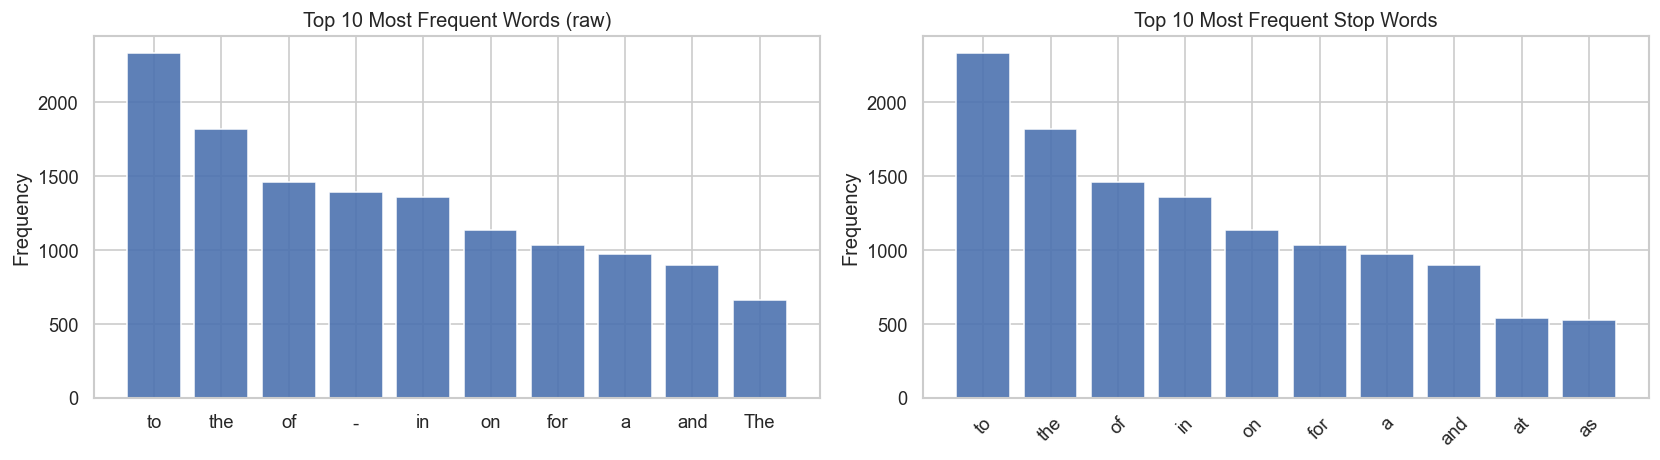


There is in total 116218 words in the train dataset
16.95% are stop words


In [22]:
train['word_count'] = train['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))


all_words = ' '.join(train['text']).split()
freq      = pd.Series(all_words).value_counts()
top10     = freq.head(10)
axes[0].bar(top10.index, top10.values, alpha=0.9)
axes[0].set_title('Top 10 Most Frequent Words (raw)')
axes[0].set_ylabel('Frequency')

freq_sw      = pd.Series([w for w in all_words if w in stop_words]).value_counts()
top10_sw     = freq_sw.head(10)
axes[1].bar(top10_sw.index, top10_sw.values, alpha=0.9)
axes[1].set_title('Top 10 Most Frequent Stop Words')
axes[1].set_ylabel('Frequency')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print()


freq_sw.sort_values(ascending=False)[0:10]
print(f'There is in total {sum(freq)} words in the train dataset\n{sum(freq_sw)/sum(freq)*100:.2f}% are stop words')



#### 5.2.2 Punctuation 

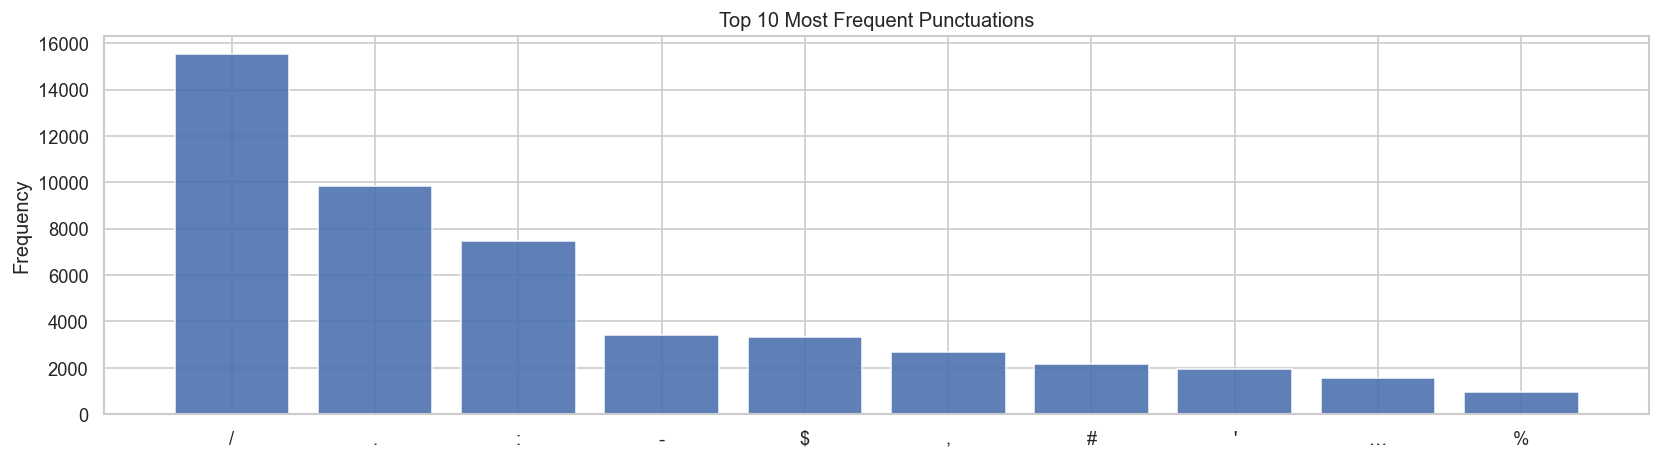


Most Frequent Punctuation 


/    15524
.     9849
:     7472
-     3396
$     3310
,     2685
#     2182
'     1943
…     1573
%      945
Name: count, dtype: int64

In [23]:
fig, axes = plt.subplots(1, 1, figsize=(14, 4))

all_punct = re.findall(r'[^\w\s]', ' '.join(train['text'].fillna('')))
freq_punct      = pd.Series(all_punct).value_counts()
top10     = freq_punct.head(10)
axes.bar(top10.index, top10.values, alpha=0.9)
axes.set_title('Top 10 Most Frequent Punctuations')
axes.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print()
print('Most Frequent Punctuation ')

freq_punct.sort_values(ascending=False)[0:10]


Emojis may be important also to determine the sentiment of the tweet

In [26]:
all_emoji = [c for c in ' '.join(train['text'].fillna('')) if c in emoji.EMOJI_DATA]
freq_emoji = pd.Series(all_emoji).value_counts()
top10      = freq_emoji.head(10)

has_emoji = train['text'].apply(lambda x: any(c in emoji.EMOJI_DATA for c in str(x)))

print(f'There are in total {sum(freq_emoji)} emojis')
print('Most Frequent Emojis:')
freq_emoji.sort_values(ascending=False)[0:60]

There are in total 60 emojis
Most Frequent Emojis:


®    9
⚡    4
©    3
▶    3
✅    3
📈    2
™    2
👀    2
▪    2
🔔    2
🤔    1
♀    1
😳    1
👍    1
🌴    1
☀    1
🎄    1
⚧    1
🏫    1
❄    1
🌍    1
🥑    1
🎶    1
⬆    1
🐢    1
🎤    1
😀    1
🔄    1
🌏    1
😷    1
📱    1
♻    1
🏞    1
🏎    1
🎧    1
📰    1
➡    1
👋    1
Name: count, dtype: int64

In [27]:
for label_id, label_name in {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}.items():
    subset = train[(train['label'] == label_id) & has_emoji]
    print(f'\n{label_name}: {len(subset)} tweets with emojis')
    


Bearish: 0 tweets with emojis

Bullish: 3 tweets with emojis

Neutral: 47 tweets with emojis


#### 5.2.3 Dates

In [28]:
dates = re.findall(r'\d{2,4}[-/_.]\d{2}[-/_.]\d{2,4}', ' '.join(train['text'].fillna('')))
freq_dates      = pd.Series(dates).value_counts()
top10     = freq_dates.head(10)


print(f'There are {sum(freq_dates)} dates in the dataset\n')

print('Most Frequent Dates')

freq_dates.sort_values(ascending=False)[0:10]

There are 22 dates in the dataset

Most Frequent Dates


11/25/19      2
15/12/19      2
12/17/2019    2
22/11/2019    1
25.11.2019    1
31/10/19      1
12/15/2019    1
11-25-19      1
12/13/19      1
12/16/2019    1
Name: count, dtype: int64

#### 5.2.4 Words in capslock

In [29]:
all_caps = re.findall(r'\b[A-Z]{2,}\b', ' '.join(train['text'].fillna('')))
freq_caps      = pd.Series(all_caps).value_counts()

print(f'There are {sum(freq_caps)} words in capslock in the dataset\n')

print('Most Frequent Caps Words - Word Count:')

freq_caps.sort_values(ascending=False)[0:20]


There are 6912 words in capslock in the dataset

Most Frequent Caps Words - Word Count:


EPS       188
CEO       178
NASDAQ    116
NYSE      109
GMT        89
US         85
OPEC       47
IPO        44
UPDATE     41
EU         39
USD        34
UK         34
WTI        33
CFO        33
TSE        29
SPY        27
FDA        27
AT         27
LVMH       27
ETF        26
Name: count, dtype: int64

#### **Conclusion**


- For **stopwords**, since removing them in sentimental analysys is a grey area, as words like "not", "but", and "however" can reverse the sentiment of a sentence, we will keep them . 
- Like said before the **url** don't give any new information of the sentiment of the tweet so it will be removed;
- For **punctiontion**, according to our project goal pucntions like ``!``,``?``, and ``emojis`` express emotions, and numerical symbols like ``$``,``£``,``%``,``.`` are important. Symbols like `@`, ``"``, ``()``, ``---``, ``...``, ``*``, most likley are noise. So we will not remove the numerical nor the punctionation that express emotion;
- For **numbers**, they can represent the amount of money loss in the stock market meaning it's a necessary info;
- For **dates** since there are only 22 of them in the dataset and they don't carry any sentiment, they will remove them;
-For **casing**, we will lowercase all words to normalize the text, ensuring that the same word in different cases (e.g. "USD", "Usd", "usd") is treated as a single token. Although all-caps words can carry sentiment signal in tweets, we accept this tradeoff for consistency. **Lemmatization** further reduces different forms of the same word (e.g. "trading", "traded", "trade") to a single base form.

Application of a formula that will:

1. Put everything in lowercase
2. Remove the url links
3. Remove noisy characters - keeping the numerical punctiation and the emojis
4. Remove dates
5. Lematize



In [30]:
# Snowball stemmer to reduce words to their root form
stemmer = SnowballStemmer('english')

# WordNet lemmatizer to convert words to their base or dictionary form
lemma = WordNetLemmatizer()


def clean(text_list,stopwords=True, lemmatize=True, stem=False):
    """
    Clean a list of text strings:
      - lowercase
      - remove non-letter characters (punctuation, URLs)
      - optionally lemmatize or stem
    """
    clean_text = []
    for text in tqdm(text_list):
        text = str(text).lower()
        text = re.sub(r'https?://\S+', '', text)                        # remove URLs
        
        emojis = ''.join(c for c in text if c in emoji.EMOJI_DATA) # extract emojis before cleaning       
        text = re.sub(r'[^\w\s!?.,\$%€£]', ' ', text)              # clean text but keep important punctuation
        text = text + ' ' + emojis                                 # add emojis back at the end
        text = re.sub('br', '', text)                              # remove HTML <br>
        text= re.sub(r'\d{2,4}[-/_.]\d{2}[-/_.]\d{2,4}', '', text)
        if stopwords:
            text = " ".join([word for word in text.split() if word not in stop])
        # Lemmatize
        if lemmatize:
            text = ' '.join(lemma.lemmatize(word) for word in text.split())
        # Stemming
        if stem:
            text = ' '.join(stemmer.stem(word) for word in text.split())
        clean_text.append(text)
    
    return clean_text


# Apply cleaning function
train['clean_text'] = clean(train['text'], stopwords=False, lemmatize=True, stem=False)

# View original and cleaned texts
train[['text', 'clean_text']].head()

100%|██████████| 9543/9543 [00:06<00:00, 1483.01it/s]


,text,clean_text
0,$BYND - JPMorgan reels in expectations on Beyo...,$bynd jpmorgan reel in expectation on beyond meat
1,$CCL $RCL - Nomura points to bookings weakness...,$ccl $rcl nomura point to booking weakness at ...
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...","$cx cemex cut at credit suisse, j.p. morgan on..."
3,$ESS: BTIG Research cuts to Neutral https://t....,$ess btig research cut to neutral
4,$FNKO - Funko slides after Piper Jaffray PT cu...,$fnko funko slide after piper jaffray pt cut


## 6. Corpus Split

To start our modeling phase we will split the train.csv data to a train and validation sets, where 80% will be used for training and 20% for validation.<br>
We will use two versions of the data depending on the model:
- **Cleaned text** (clean_text): with all the preprocessing steps appliedthroughout this notebook (lowercasing, URL removal, lemmatization, etc.),used for traditional models such as Logistic Regression and KNN;
- **Raw text** (text): the original untouched version of the dataset, used for pre-trained transformer models such as BERT and RoBERTa, since these models have their own internal tokenizer and were already pretrained on natural text.

In [31]:
# Split for models with cleaned text 
X_train = train['clean_text']
y_train = train['label'] 

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=2)

In [32]:
# Split for models with raw text (for PRE-TRAINED MODELS)
X_raw = train['text']
y_raw = train['label'] 
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=2)

## 7. Feature Engineering

### 7.1 Bag of Words (BoW) Features

Each unique word in the corpus becomes a feature. A document is represented as a binary vector indicating which vocabulary words it contains (`binary=True`).

**Vocabulary** = the set of all words seen in the training corpus.  
**Document vector** = a binary indicator over the full vocabulary.

We experiment BoW with two variations:
#### **1. CountVectorizer**
Each position in the vector contains the **raw count** of how many times that word appears in the tweet.

#### **2. TF-IDF (Term Frequency: Inverse Document Frequency)**
Instead of raw counts, each position contains a **weight** based on two factors:
- **TF**: how often the word appears in that tweet
- **IDF**: how rare the word is across all tweets

Both produce a sparse matrix of shape (n_tweets*5000) where most values are zero since each tweet only contains a tiny fraction of the full vocabulary.

In [ ]:
def bow_or_tfidf(texts, method='bow', max_features=5000):
    """
    Convert a list of text documents into a numerical feature matrix using either
    Bag of Words (BoW) or TF-IDF vectorization.

    Parameters:
        texts (list or pandas Series): Collection of text documents to vectorize.
        method (str): 'bow' for CountVectorizer or 'tfidf' for TF-IDF. Default is 'bow'.
        max_features (int): Maximum number of features (vocabulary size). Default is 5000.

    Returns:
        X (scipy sparse matrix): The document-term matrix.
        vectorizer: The fitted vectorizer instance.

    Raises:
        ValueError: If the provided method is not 'bow' or 'tfidf'.
    """
    if method == 'bow':
        vectorizer = CountVectorizer(max_features=max_features)
    elif method == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=max_features)
    else:
        raise ValueError("Choose a valid method: 'bow' or 'tfidf'.")

    X = vectorizer.fit_transform(texts)
    return X, vectorizer

#### 7.1.1 CountVectorizer


In [36]:
X_train_bow, bow_vectorizer = bow_or_tfidf(X_train, method='bow')
X_val_bow = bow_vectorizer.transform(X_val)

print(f'Documents  (rows)   : {X_train_bow.shape[0]:,}')
print(f'Vocabulary (columns): {X_train_bow.shape[1]:,}')
print(f'Non-zero entries    : {X_train_bow.nnz:,}')

density = X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]) * 100
print(f'Matrix density      : {density:.4f}%  <- almost all zeros (sparse matrix)')

Documents  (rows)   : 7,634
Vocabulary (columns): 5,000
Non-zero entries    : 74,027
Matrix density      : 0.1939%  <- almost all zeros (sparse matrix)


In [37]:
print('BoW vectors for documents 10-12:')
print(X_train_bow[10:13].toarray())

print('\nSample vocabulary terms (positions 0-20):')
print(bow_vectorizer.get_feature_names_out()[0:20])

BoW vectors for documents 10-12:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Sample vocabulary terms (positions 0-20):
['00' '000' '00am' '00pm' '01' '02' '03' '04' '05' '06' '07' '08' '09'
 '10' '100' '1000' '100m' '105' '108' '11']


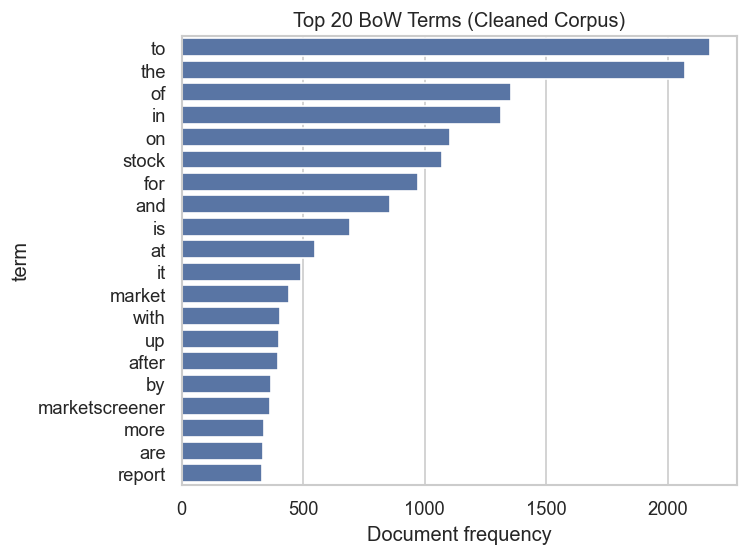

In [40]:
bow_sum   = np.array(X_train_bow.sum(axis=0)).flatten()
bow_terms = bow_vectorizer.get_feature_names_out()
top20     = pd.DataFrame({'term': bow_terms, 'count': bow_sum}).sort_values('count', ascending=False).head(20)

sns.barplot(data=top20, x='count', y='term')
plt.title('Top 20 BoW Terms (Cleaned Corpus)')
plt.xlabel('Document frequency')
plt.tight_layout()
plt.show()

#### 7.1.2 TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) is an improvement over simple BoW counting and is considered a variation of BoW.

In [41]:
X_train_tfidf, tfidf_vectorizer = bow_or_tfidf(X_train, method='tfidf')
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# Shape
print(f'Documents  (rows)   : {X_train_tfidf.shape[0]:,}')
print(f'Vocabulary (columns): {X_train_tfidf.shape[1]:,}')

# Show TF-IDF weights for the first tweet
first_tweet = X_train.iloc[0]
first_vec   = X_train_tfidf[0]
tfidf_terms = tfidf_vectorizer.get_feature_names_out()
nonzero_idx = first_vec.nonzero()[1]

print(f'\nOriginal tweet : {first_tweet}')
print('TF-IDF weights :')
for i in nonzero_idx:
    print(f'  {tfidf_terms[i]:<20} {first_vec[0, i]:.4f}')


Documents  (rows)   : 7,634
Vocabulary (columns): 5,000

Original tweet : home depot fall sharply after release of 3rd quarter result
TF-IDF weights :
  home                 0.3147
  depot                0.3680
  fall                 0.3037
  sharply              0.4076
  after                0.2110
  release              0.3762
  of                   0.1504
  3rd                  0.4076
  quarter              0.2847
  result               0.2266


In [47]:
# Show the full vector for the first tweet
print(f'\nFull TF-IDF vector for tweet 0 (first 20 values):')
print(X_train_tfidf[0].toarray()[0][:20].round(4))

print(f'\nVector shape : {X_train_tfidf[0].toarray().shape}')
print(f'Non-zero positions : {first_vec.nnz} out of {X_train_tfidf.shape[1]}')

# Show side by side: word → position → weight
print(f'\nWord → Position → TF-IDF weight:')
for i in nonzero_idx:
    print(f'  {tfidf_terms[i]:<20} position {i:<6} weight: {first_vec[0, i]:.4f}')


Full TF-IDF vector for tweet 0 (first 20 values):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Vector shape : (1, 5000)
Non-zero positions : 10 out of 5000

Word → Position → TF-IDF weight:
  home                 position 1747   weight: 0.3147
  depot                position 1028   weight: 0.3680
  fall                 position 1324   weight: 0.3037
  sharply              position 3872   weight: 0.4076
  after                position 225    weight: 0.2110
  release              position 3475   weight: 0.3762
  of                   position 2849   weight: 0.1504
  3rd                  position 86     weight: 0.4076
  quarter              position 3349   weight: 0.2847
  result               position 3555   weight: 0.2266


### 7.2 Word2Vec

Unlike BoW, **Word2Vec** learns the **meaning** of words by looking at the context they appear in, meaning that words that appear in similar contexts get similar vectors.

Each word becomes a **dense vector of 100 numbers**. Since we need one vector per tweet, we **average all word vectors** in the tweet into a single vector.

There's 3 variations of Word2Vec:

| | Skip-gram | CBOW | GloVe |
|---|---|---|---|
| Input | center word | context words | whole corpus |
| Predicts | context words | center word | word co-occurrence |
| Better for | rare words | frequent words | all words |
| Speed | slower | faster | fastest (pre-loaded) |

#### 7.2.1 Skip-Gram


In [44]:
# Train Word2Vec on training data only
tokenized_train = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,  # each word becomes a vector of 100 numbers
    window=2,         # context window size
    min_count=1,      # minimum word frequency to be included
    sg=1              # 1 = Skip-gram, 0 = CBOW
)

word_vectors = w2v_model.wv
print(f'Vocabulary size : {len(word_vectors.index_to_key)}')
print(f'Vector size     : {w2v_model.vector_size}')

# Helper function: average word vectors into one document vector
def get_doc_embedding(doc, word_vectors, dim=100):
    tokens = doc.split()
    vectors = [word_vectors[word] for word in tokens if word in word_vectors.index_to_key]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dim)

# Generate embeddings
X_train_w2v = np.vstack([get_doc_embedding(doc, word_vectors) for doc in X_train])
X_val_w2v   = np.vstack([get_doc_embedding(doc, word_vectors) for doc in X_val])

print(f'\nX_train_w2v shape : {X_train_w2v.shape}')  # (n_tweets, 100)
print(f'X_val_w2v shape   : {X_val_w2v.shape}')

# Sanity check: similar words to 'stock'
print('\nWords most similar to "stock":')
print(w2v_model.wv.most_similar('stock', topn=5))

Vocabulary size : 15707
Vector size     : 100

X_train_w2v shape : (7634, 100)
X_val_w2v shape   : (1909, 100)

Words most similar to "stock":
[('economy', 0.9828193187713623), ('roundup', 0.917795717716217), ('renascorresources', 0.9153426289558411), ('trading', 0.9149735569953918), ('wti', 0.9133362770080566)]


In [45]:
example_tweet = X_train.iloc[0]
example_vec   = get_doc_embedding(example_tweet, word_vectors)

print(f'\nOriginal tweet : {example_tweet}')
print(f'Embedding shape: {example_vec.shape}')
print(f'First 10 values: {example_vec[:10].round(4)}')


Original tweet : home depot fall sharply after release of 3rd quarter result
Embedding shape: (100,)
First 10 values: [-0.3272  0.2608  0.0929  0.1488  0.0842 -0.3223  0.0547  0.4275 -0.2958
 -0.0064]


#### 7.2.2 CBOW (Continuous Bag of Words)

**CBOW** is the second training approach of Word2Vec. While Skip-gram predicts the surrounding context words given a center word, CBOW does the opposite.

In [ ]:
w2v_model_cbow = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=2,
    min_count=1,
    sg=0              # 0 = CBOW
)

word_vectors_cbow = w2v_model_cbow.wv

# Generate embeddings
X_train_w2v_cbow = np.vstack([get_doc_embedding(doc, word_vectors_cbow) for doc in X_train])
X_val_w2v_cbow   = np.vstack([get_doc_embedding(doc, word_vectors_cbow) for doc in X_val])

print(f'Vocabulary size        : {len(word_vectors_cbow.index_to_key)}')
print(f'X_train_w2v_cbow shape : {X_train_w2v_cbow.shape}')
print(f'X_val_w2v_cbow shape   : {X_val_w2v_cbow.shape}')

# Sanity check — compare with Skip-gram results
print('\nWords most similar to "stock" (CBOW):')
for word, score in w2v_model_cbow.wv.most_similar('stock', topn=5):
    print(f'  {word:<20} similarity: {score:.4f}')

Vocabulary size        : 15707
X_train_w2v_cbow shape : (7634, 100)
X_val_w2v_cbow shape   : (1909, 100)

Words most similar to "stock" (CBOW):
  economy              similarity: 0.9977
  wti                  similarity: 0.9882
  roundup              similarity: 0.9869
  index                similarity: 0.9861
  investing            similarity: 0.9860


#### 7.2.3 GloVe 

**GloVe** is a pre-trained word embedding model developed by Stanford.
Unlike Word2Vec which learns from local context windows, GloVe learns from **how often words appear together** across the entire corpus.

In [50]:
model_name = 'glove-twitter'
emb_size = 100

w2v = gensim.downloader.load(f'{model_name}-{emb_size}')

def corpus2vec(corpus, w2v):
    """
    Convert a list of text documents into lists of word vectors using a pre-trained GloVe model.

    Parameters:
    corpus (list): List of strings, each representing a document (e.g., tweet).
    w2v (gensim KeyedVectors): Pre-trained word vectors loaded via gensim.

    Returns:
    list: A list where each element is a list of word vectors corresponding to the words in a document.
    """
    index_set = set(w2v.index_to_key)  # For fast lookup
    word_vec = w2v.get_vector          # Shortcut for faster access
    return [
        [word_vec(word) for word in doc.split() if word in index_set]
        for doc in tqdm(corpus)
    ]

# Apply to training and validation data
x_train_vec = corpus2vec(X_train, w2v)
x_val_vec = corpus2vec(X_val, w2v)

# Function to convert each tweet into a single vector (average of its word vectors)
def average_vectors(vector_list, dim):
    """
    Compute the average vector for a list of word vectors.
    If the list is empty, return a zero vector.

    Parameters:
    vector_list (list): List of word vectors (e.g., from a tweet).
    dim (int): Dimensionality of the embeddings.

    Returns:
    numpy.ndarray: Averaged vector representation of the input list.
    """
    return np.mean(vector_list, axis=0) if vector_list else np.zeros(dim)

# Generate averaged document embeddings for training and validation sets
X_train_glove_avg = np.vstack([average_vectors(vecs, emb_size) for vecs in x_train_vec])
X_val_glove_avg = np.vstack([average_vectors(vecs, emb_size) for vecs in x_val_vec])

100%|██████████| 1909/1909 [00:00<00:00, 27301.02it/s]
